In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load your dataset
df = pd.read_csv("../dataset/teams.csv")

# Quick overview
df.head()

,year,lgID,tmID,franchID,confID,divID,rank,playoff,seeded,firstRound,...,GP,homeW,homeL,awayW,awayL,confW,confL,min,attend,arena
0,9,WNBA,ATL,ATL,EA,NaN,7,N,0,NaN,...,34,1,16,3,14,2,18,6825,141379,Philips Arena
1,10,WNBA,ATL,ATL,EA,NaN,2,Y,0,L,...,34,12,5,6,11,10,12,6950,120737,Philips Arena
2,1,WNBA,CHA,CHA,EA,NaN,8,N,0,NaN,...,32,5,11,3,13,5,16,6475,90963,Charlotte Coliseum
3,2,WNBA,CHA,CHA,EA,NaN,4,Y,0,W,...,32,11,5,7,9,15,6,6500,105525,Charlotte Coliseum
4,3,WNBA,CHA,CHA,EA,NaN,2,Y,0,L,...,32,11,5,7,9,12,9,6450,106670,Charlotte Coliseum


In [14]:
# Calculate win percentage
df["win_pct"] = df["won"] / (df["won"] + df["lost"])

#Add win_pct as feature to the dataset
df[["year", "tmID", "confID", "rank", "win_pct"]].head()

print(df.head())

   year  lgID tmID franchID confID  divID  rank playoff  seeded firstRound  \
0     9  WNBA  ATL      ATL     EA    NaN     7       N       0        NaN   
1    10  WNBA  ATL      ATL     EA    NaN     2       Y       0          L   
2     1  WNBA  CHA      CHA     EA    NaN     8       N       0        NaN   
3     2  WNBA  CHA      CHA     EA    NaN     4       Y       0          W   
4     3  WNBA  CHA      CHA     EA    NaN     2       Y       0          L   

   ... homeW homeL awayW  awayL  confW  confL   min  attend  \
0  ...     1    16     3     14      2     18  6825  141379   
1  ...    12     5     6     11     10     12  6950  120737   
2  ...     5    11     3     13      5     16  6475   90963   
3  ...    11     5     7      9     15      6  6500  105525   
4  ...    11     5     7      9     12      9  6450  106670   

                arena   win_pct  
0       Philips Arena  0.117647  
1       Philips Arena  0.529412  
2  Charlotte Coliseum  0.250000  
3  Charlotte Col

In [15]:
# Compute correlation matrix
corr = df[["rank", "win_pct"]].corr()

# Show correlation with rank
corr["rank"].sort_values()


win_pct   -0.887239
rank       1.000000
Name: rank, dtype: float64

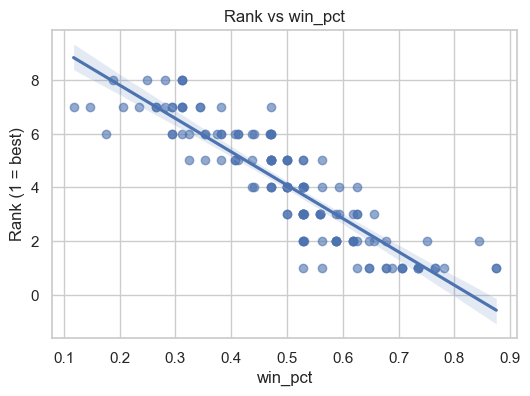

In [17]:
# Set style
sns.set(style="whitegrid", context="notebook")

features = ["win_pct"]

for col in features:
    plt.figure(figsize=(6, 4))
    sns.regplot(x=col, y="rank", data=df, scatter_kws={"alpha":0.6})
    plt.title(f"Rank vs {col}")
    plt.xlabel(col)
    plt.ylabel("Rank (1 = best)")
    plt.show()
